# Leakage-Safe Future Regime-Transition Targets (Stage 11)

## 1. Why future targets are needed

Regime assignments describe the market condition at each observation. Prediction requires a distinct outcome dated after the forecast origin. Stage 11 therefore converts the finalized forward-filtered HMM states into future transition targets without using volume, VIX, future returns, or smoothed states. It is descriptive target engineering only and makes no claim about volume predictability.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT=Path.cwd()
if ROOT.name=='notebooks': ROOT=ROOT.parent
T=ROOT/'outputs'/'tables'; F=ROOT/'outputs'/'figures'
market=pd.read_csv(T/'market_with_transition_targets.csv')
summary=pd.read_csv(T/'transition_target_summary.csv')
counts=pd.read_csv(T/'filtered_transition_counts.csv')
episodes=pd.read_csv(T/'filtered_episode_summary.csv')
confidence=pd.read_csv(T/'transition_confidence_summary.csv')
print(f'Loaded {len(market):,} rows and {len(market.columns)} columns from generated Stage 11 outputs.')

Loaded 6,641 rows and 117 columns from generated Stage 11 outputs.


## 2. Three distinct transition concepts

A next-observation transition asks whether $S_{t+1}\ne S_t$. Any transition within horizon $h$ asks whether at least one of $S_{t+1},\ldots,S_{t+h}$ differs from $S_t$, even if the state later returns. Endpoint transition asks only whether $S_{t+h}\ne S_t$. These questions are not interchangeable.

## 3. Stress-oriented outcomes

Lower stress is fixed as Ordered States 1–2; higher stress is States 3–4; acute stress is State 4. Stress entry applies only when the current state is lower stress. Stress exit applies only when it is higher stress. Acute entry applies only outside State 4. Worsening means reaching a numerically higher ordered state and is inapplicable in State 4; improving means reaching a lower state and is inapplicable in State 1.

## 4. Missingness, complete windows, and purging

Structurally inapplicable outcomes are missing rather than zero because the corresponding event is not at risk. A target also requires the complete next-$h$ observation window and eligible filtered states throughout; therefore the final $h$ rows are unavailable. Nominal training rows whose outcomes cross 2017-12-31 are labeled `Purged`, preventing later training from consuming test-period outcomes.

## 5. Why filtered states define outcomes

`HMM_Filtered_State` uses observations available through each date. Future filtered states can serve as subsequently realized outcomes, but not as predictors at time $t$. Smoothed states use the full sequence and are excluded. Overlapping multi-observation windows share future states, creating serial dependence that later inference must address.

## 6. Counts, prevalence, and class imbalance

Five trading observations is the prespecified primary horizon. One, ten, and twenty observations are sensitivity horizons. The table below reports denominators explicitly; rare stress and acute entries should be treated as class-imbalance facts, not hidden by accuracy summaries.

In [2]:
focus=['Any_Transition_Within','Stress_Entry_Within','Stress_Exit_Within','Acute_Entry_Within']
summary.loc[(summary['sample'].isin(['Train','Test'])) & summary.apply(lambda r:any(r.target==f'{x}_{r.horizon}D' for x in focus),axis=1),
 ['horizon','target','sample','available_observations','positives','negatives','event_rate']].round(4)

,horizon,target,sample,available_observations,positives,negatives,event_rate
1,1,Any_Transition_Within_1D,Train,4276,172,4104,0.0402
2,1,Any_Transition_Within_1D,Test,2112,90,2022,0.0426
7,1,Stress_Entry_Within_1D,Train,2828,13,2815,0.0046
8,1,Stress_Entry_Within_1D,Test,1429,12,1417,0.0084
10,1,Stress_Exit_Within_1D,Train,1448,14,1434,0.0097
11,1,Stress_Exit_Within_1D,Test,683,12,671,0.0176
13,1,Acute_Entry_Within_1D,Train,3915,8,3907,0.0020
14,1,Acute_Entry_Within_1D,Test,2031,4,2027,0.0020
22,5,Any_Transition_Within_5D,Train,4272,746,3526,0.1746
23,5,Any_Transition_Within_5D,Test,2108,420,1688,0.1992


In [3]:
pd.DataFrame({'Horizon':[1,5,10,20],
 'Purged_rows':[int((market[f'Transition_Sample_{h}D']=="Purged").sum()) for h in [1,5,10,20]],
 'Unavailable_rows':[int((market[f'Transition_Sample_{h}D']=="Unavailable").sum()) for h in [1,5,10,20]]})

,Horizon,Purged_rows,Unavailable_rows
0,1,1,252
1,5,5,256
2,10,10,261
3,20,20,271


## 7. Empirical transitions and episodes

The adjacent transition table describes realized filtered assignments and is separate from the fitted HMM parameter transition matrix. Episodes that cross the cutoff are explicitly labeled rather than assigned wholly to training or testing.

In [4]:
display(counts.loc[counts.Sample.eq('All'),['From_State_Label','To_State_Label','Count','Empirical_Probability']].round(4))
episodes.round(3)

,From_State_Label,To_State_Label,Count,Empirical_Probability
0,Ordered_State_1,Ordered_State_1,2104,0.9577
1,Ordered_State_1,Ordered_State_2,93,0.0423
2,Ordered_State_1,Ordered_State_3,0,0.0000
3,Ordered_State_1,Ordered_State_4,0,0.0000
4,Ordered_State_2,Ordered_State_1,94,0.0456
5,Ordered_State_2,Ordered_State_2,1942,0.9423
6,Ordered_State_2,Ordered_State_3,25,0.0121
7,Ordered_State_2,Ordered_State_4,0,0.0000
8,Ordered_State_3,Ordered_State_1,0,0.0000
9,Ordered_State_3,Ordered_State_2,26,0.0154


,Sample,Ordered_State,Episode_Count,Mean_Length,Median_Length,Std_Length,Minimum_Length,Maximum_Length,Q25_Length,Q75_Length,Q90_Length
0,All,1,94,23.383,16.0,28.373,1.0,191.0,5.00,31.50,46.0
1,All,2,119,17.319,15.0,15.294,1.0,68.0,5.00,22.00,40.0
2,All,3,38,44.447,21.0,53.825,3.0,215.0,10.00,52.25,94.6
3,All,4,12,36.833,23.5,56.849,2.0,211.0,8.50,33.50,46.7
4,Train,1,64,21.922,13.0,30.754,1.0,191.0,3.00,30.50,45.7
5,Train,2,78,17.141,15.0,15.671,1.0,68.0,5.25,21.75,38.9
6,Train,3,22,49.409,33.5,58.333,3.0,215.0,9.00,73.25,95.8
7,Train,4,8,45.125,26.5,68.432,2.0,211.0,13.75,33.50,94.1
8,Test,1,29,23.586,22.0,16.330,4.0,64.0,10.00,30.00,45.2
9,Test,2,41,17.659,15.0,14.734,1.0,58.0,5.00,26.00,40.0


## 8. Confidence sensitivity

The 0.60 filtered-probability rule is diagnostic only: primary targets are unchanged. The saved summary compares all available modeled targets with windows whose current and future assignments are all high confidence, without significance tests.

In [5]:
confidence.loc[(confidence.horizon==5)&(confidence['sample']=='All'),
 ['target','all_available_count','all_event_rate','all_high_confidence_count','all_high_confidence_event_rate','excluded_by_high_confidence_restriction']].round(4)

,target,all_available_count,all_event_rate,all_high_confidence_count,all_high_confidence_event_rate,excluded_by_high_confidence_restriction
21,Any_Transition_Within_5D,6380,0.1828,5818,0.1256,562
24,Endpoint_Transition_5D,6380,0.1669,5818,0.1203,562
27,Stress_Entry_Within_5D,4249,0.0294,3856,0.0265,393
30,Stress_Exit_Within_5D,2131,0.0601,1962,0.0280,169
33,Acute_Entry_Within_5D,5938,0.0101,5418,0.0059,520
36,Stress_Worsening_Within_5D,5938,0.0941,5418,0.0794,520
39,Stress_Improving_Within_5D,4192,0.1448,3763,0.0800,429


## 9. Descriptive figures

Figure denominators are given in the preceding tables. Heatmap probabilities are empirical filtered-assignment transitions, not fitted HMM parameters; episode lengths use a log scale because durations are strongly right-skewed.

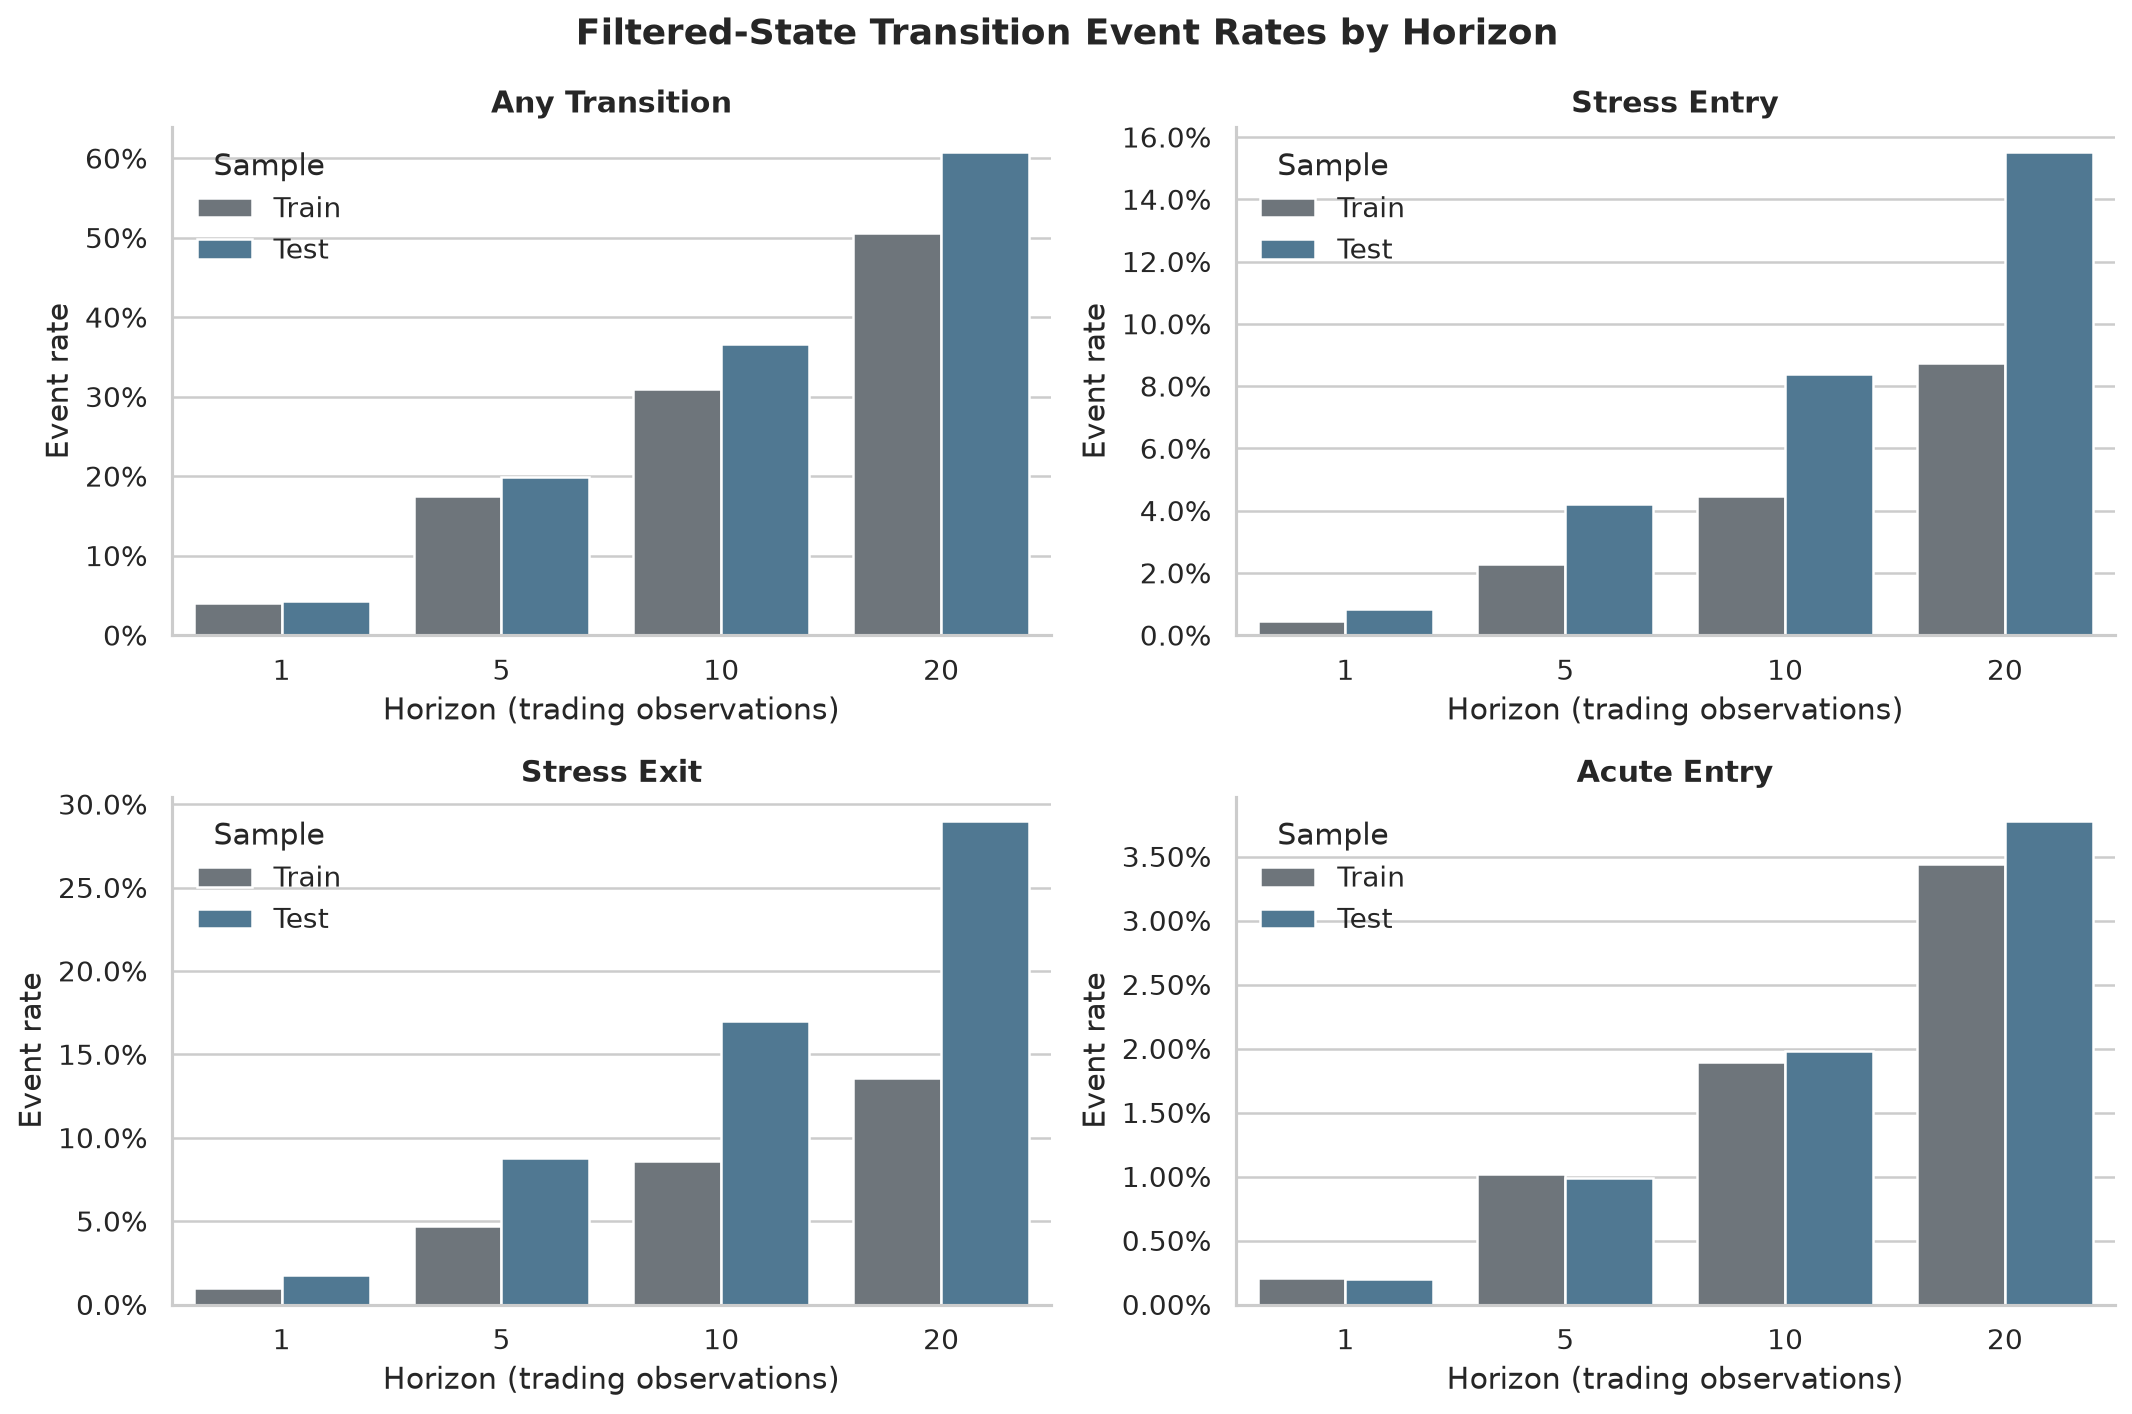

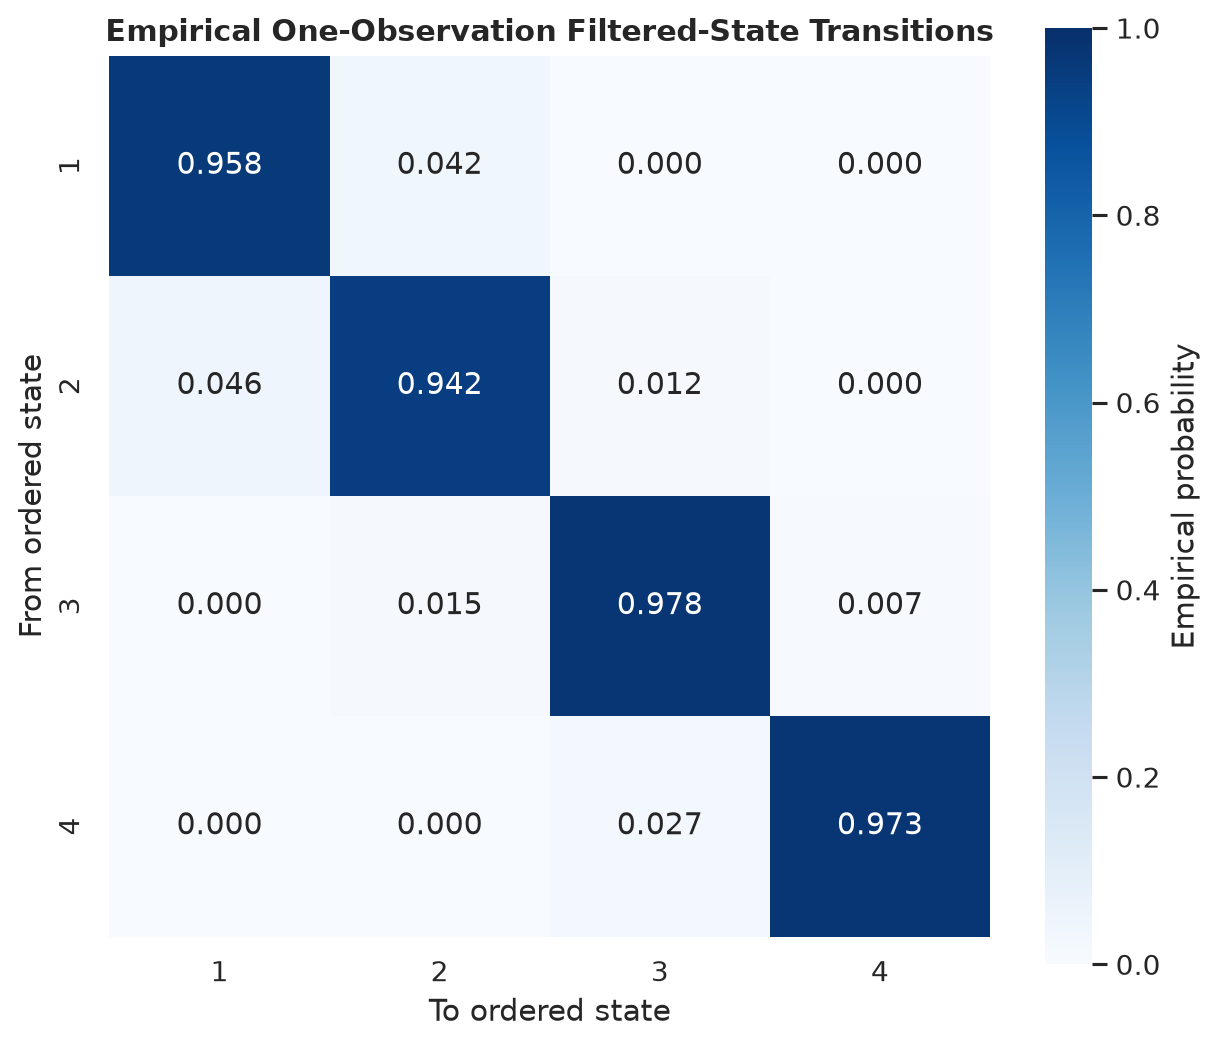

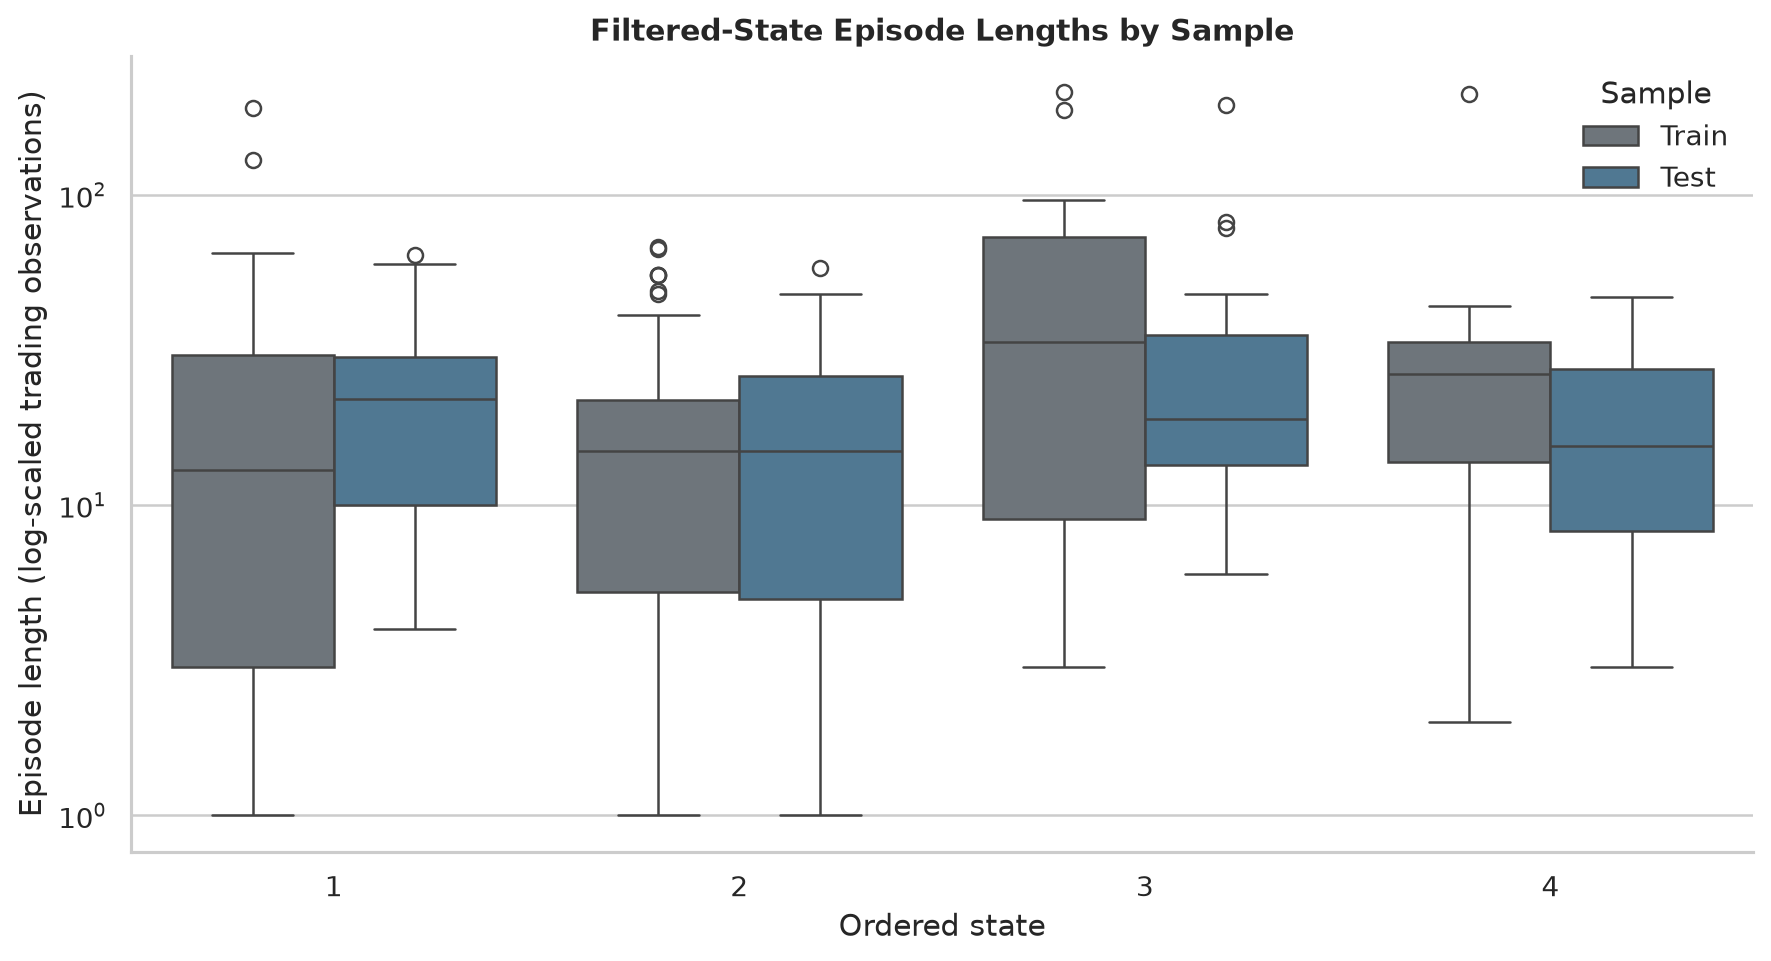

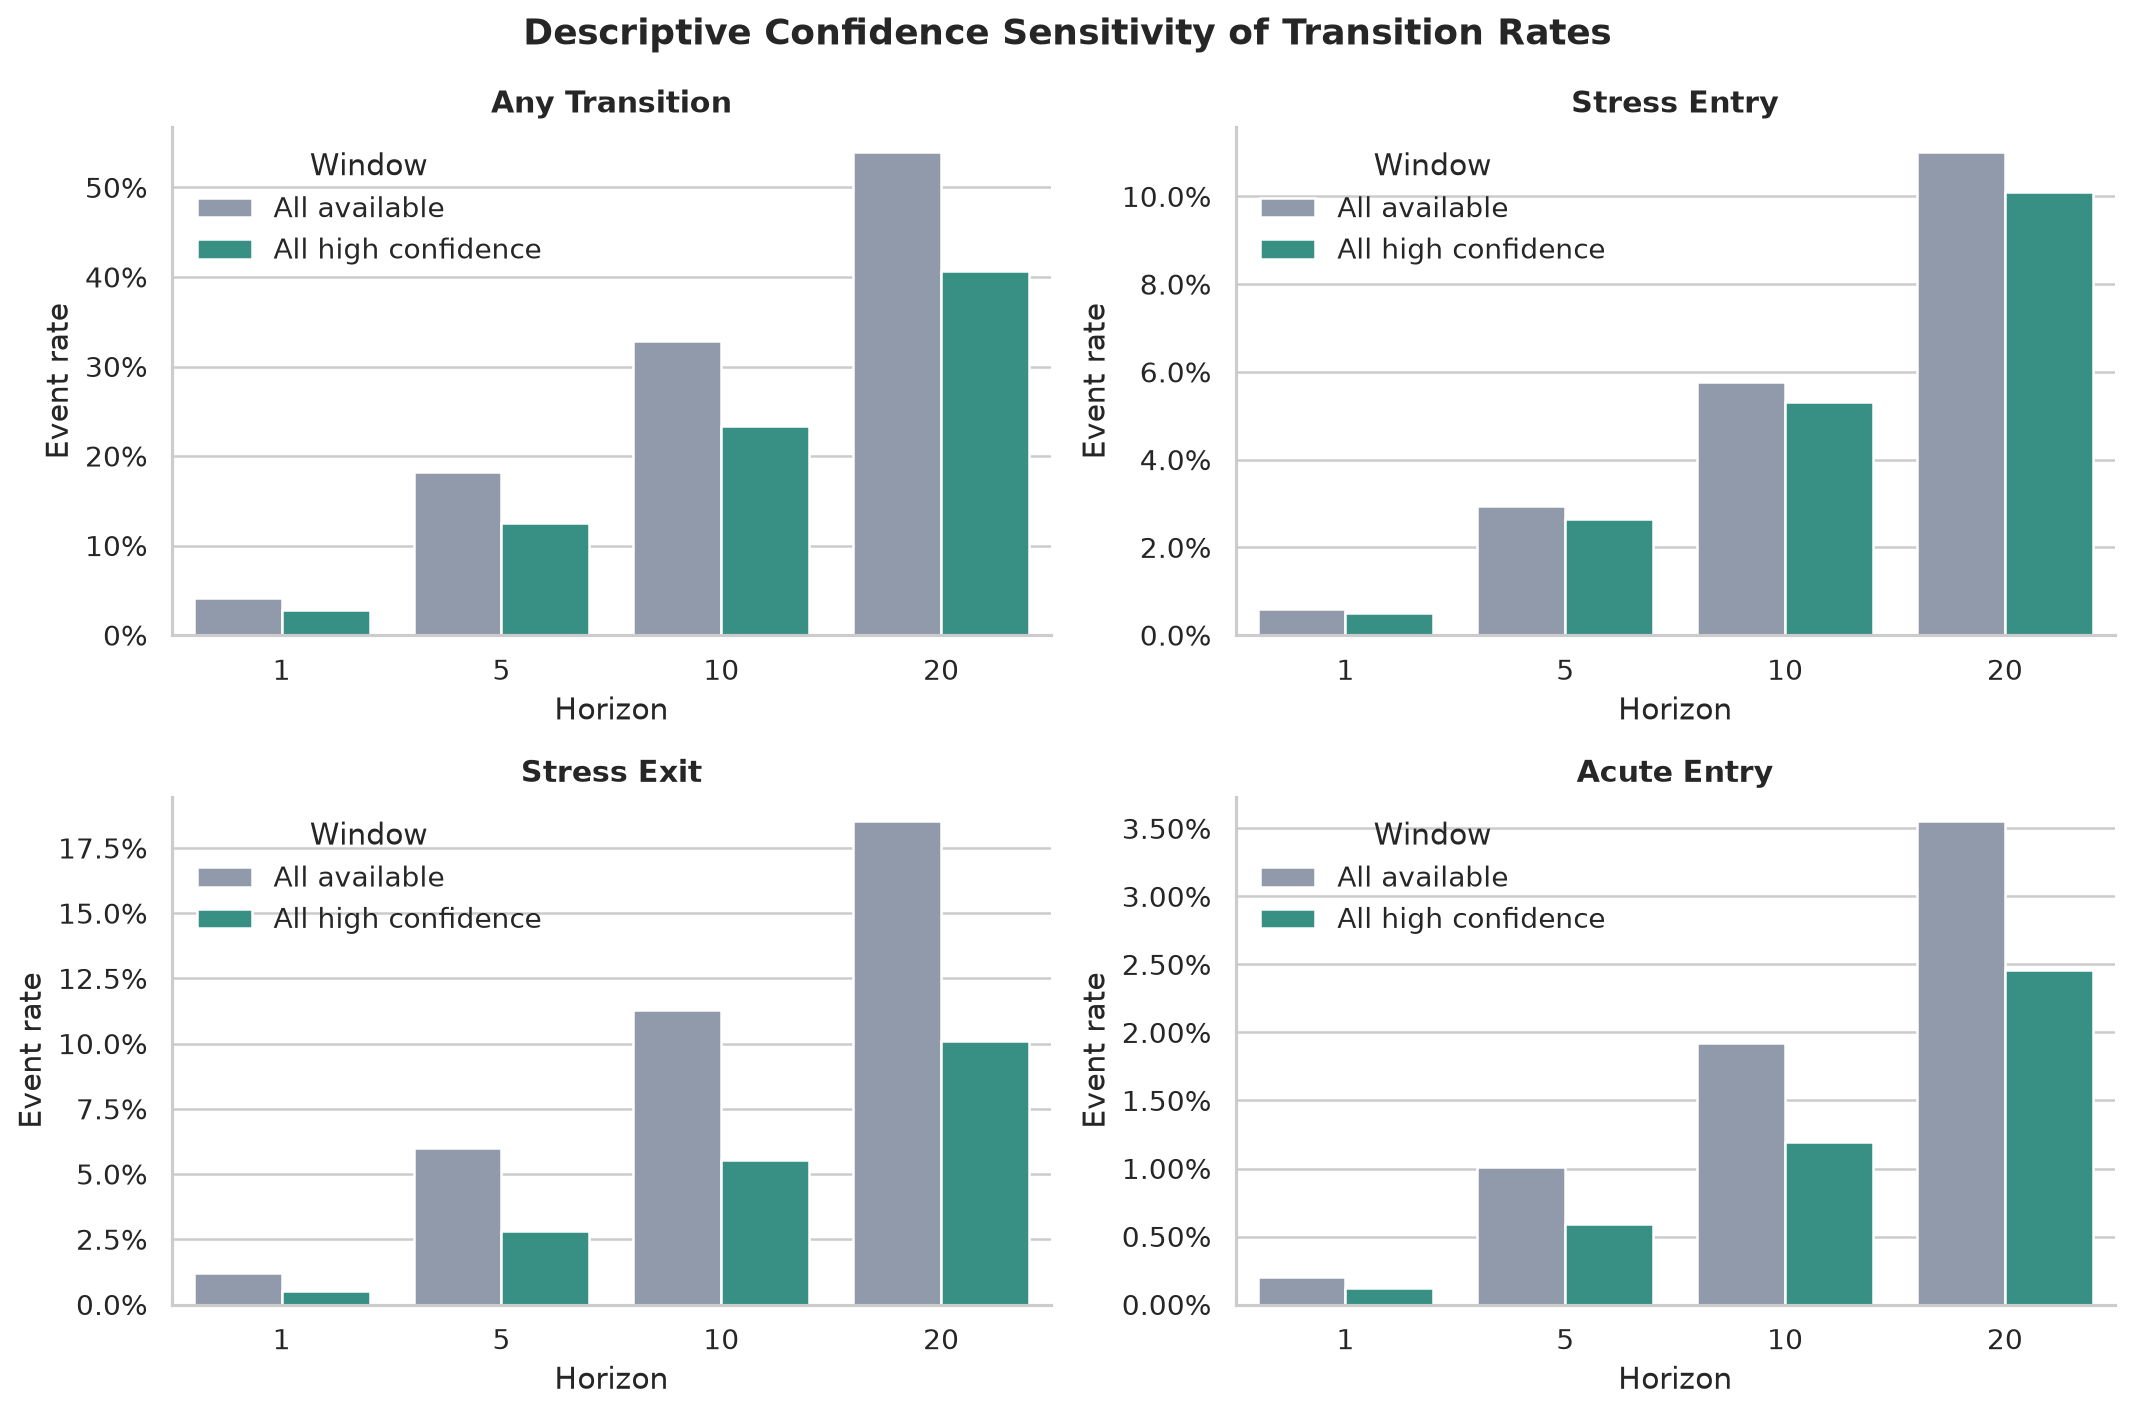

In [6]:
names=['transition_event_rates_by_horizon.png','filtered_transition_probabilities.png','filtered_episode_lengths.png','transition_confidence_sensitivity.png']
for name in names:
 p=F/name; assert p.exists() and p.stat().st_size>0; display(Image(filename=str(p),width=900))

## 10. Interpretation limits

These targets summarize future filtered-state paths. Overlapping horizons are dependent, state assignments are estimated constructs, and confidence filtering can change sample composition. No ANOVA, event-study inference, regression, causal claim, or evidence of volume predictability is presented here.